# Resumen Final del Proyecto: Consolidación y Conclusiones de Minería de Datos

Este notebook presenta un **resumen ejecutivo, comparativo y reproducible** de todos los experimentos y modelos desarrollados a lo largo del proyecto utilizando el dataset `Job Search Platform Efficacy` (100k registros).

A través de la arquitectura Medallion, organizamos el flujo de datos:
1. **Bronze (`datalake_bronze/`):** Datos raw iniciales sin procesar.
2. **Silver (`datalake_silver/`):** Datos limpios, normalizados y con variables categóricas codificadas (One-Hot Encoding).
3. **Gold (`datalake_gold/`):** Modelos finales, reportes de métricas en formato JSON, y pipelines serializados en archivos `.pkl`.

En este informe unificado, analizamos y comparamos:
* **Modelos de Clasificación Supervisada:** Para predecir si un estudiante recibirá una oferta laboral (`Offer_Received`).
* **Modelos de Regresión Supervisada:** Para estimar el salario anual ofrecido (`Offer_Salary`).
* **Algoritmos de Clustering No Supervisado:** Para identificar de forma autónoma agrupaciones naturales entre estudiantes (KMeans, Clustering Jerárquico, DBSCAN).

## 1. Configuración del Entorno de Desarrollo

En esta sección cargamos las librerías necesarias, establecemos las rutas absolutas dentro del workspace y validamos que todos los artefactos de la capa Gold estén disponibles.

In [21]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

ROOT = Path.cwd().resolve()
if ROOT.name != "mineria":
    ROOT = Path("/home/naciscric/Documents/university/2026-1/mineria")

SILVER_DIR = ROOT / "datalake_silver"
GOLD_DIR = ROOT / "datalake_gold"

CLASSIFICATION_SUMMARIES = {
    "Logistic Regression": GOLD_DIR / "outputs_logistic_regression/informe/logistic_regression_offer_received_summary.json",
    "Naive Bayes": GOLD_DIR / "outputs_naive_bayes/informe/naive_bayes_offer_received_summary.json",
    "Decision Tree": GOLD_DIR / "outputs_decision_tree/informe/decision_tree_offer_received_summary.json",
    "KNN": GOLD_DIR / "outputs_knn/informe/knn_offer_received_summary.json",
}

REGRESSION_SUMMARY = GOLD_DIR / "outputs_regresion/regresion_offer_salary_completo_summary.json"
REGRESSION_COMPARISON = GOLD_DIR / "outputs_regresion/comparacion_modelos_regresion.csv"

print(f"ROOT exists: {ROOT.exists()} -> {ROOT}")
print(f"Silver exists: {SILVER_DIR.exists()}")
print(f"Gold exists: {GOLD_DIR.exists()}")
print(f"Available classification summaries: {sum(path.exists() for path in CLASSIFICATION_SUMMARIES.values())}/{len(CLASSIFICATION_SUMMARIES)}")
print(f"Regression summary exists: {REGRESSION_SUMMARY.exists()}")
print(f"Regression comparison exists: {REGRESSION_COMPARISON.exists()}")

ROOT exists: True -> /home/naciscric/Documents/university/2026-1/mineria
Silver exists: True
Gold exists: True
Available classification summaries: 4/4
Regression summary exists: True
Regression comparison exists: True


## 2. Consolidación de Resultados de Clasificación Supervisada (`Offer_Received`)

Aquí cargamos los reportes JSON de métricas de clasificación generados por cada modelo. Adicionalmente, integramos los resultados del experimento con **Support Vector Machines (SVM)** con kernel lineal y RBF, los cuales demostraron la no linealidad del problema.

In [22]:
def load_json(path: Path) -> dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el artefacto: {path}")
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)


def metric_row(name: str, raw: dict[str, Any]) -> dict[str, Any]:
    """Normalize the different model summaries into a single table format."""
    if name == "Logistic Regression":
        metrics = raw["metrics"]
        optimized = metrics["threshold_optimized"]
        baseline = metrics["threshold_0_50"]
        return {
            "model": name,
            "task": "classification",
            "threshold": raw["best_threshold"],
            "accuracy": optimized["Accuracy"],
            "precision": optimized["Precision"],
            "recall": optimized["Recall"],
            "f1": optimized["F1-Score"],
            "roc_auc": optimized["ROC-AUC"],
            "baseline_accuracy": baseline["Accuracy"],
            "baseline_f1": baseline["F1-Score"],
            "notes": f"best_params={raw.get('best_params', {})}",
        }
    if name == "Naive Bayes":
        metrics = raw["metrics"]["threshold_optimized"]
        return {
            "model": name,
            "task": "classification",
            "threshold": raw["best_threshold"],
            "accuracy": metrics["Accuracy"],
            "precision": metrics["Precision"],
            "recall": metrics["Recall"],
            "f1": metrics["F1-Score"],
            "roc_auc": metrics["ROC-AUC"],
            "baseline_accuracy": None,
            "baseline_f1": None,
            "notes": "threshold optimized report",
        }
    if name == "Decision Tree":
        metrics = raw["metrics"]["threshold_0_50"]
        return {
            "model": name,
            "task": "classification",
            "threshold": 0.5,
            "accuracy": metrics["Accuracy"],
            "precision": metrics["Precision"],
            "recall": metrics["Recall"],
            "f1": metrics["F1-Score"],
            "roc_auc": metrics["ROC-AUC"],
            "baseline_accuracy": metrics["Accuracy"],
            "baseline_f1": metrics["F1-Score"],
            "notes": "threshold 0.50 report",
        }
    if name == "KNN":
        metrics = raw["pca_model"]["metrics"]
        return {
            "model": name,
            "task": "classification",
            "threshold": raw["pca_model"].get("best_threshold"),
            "accuracy": metrics["Accuracy"],
            "precision": metrics["Precision"],
            "recall": metrics["Recall"],
            "f1": metrics["F1-Score"],
            "roc_auc": metrics["ROC-AUC"],
            "baseline_accuracy": None,
            "baseline_f1": None,
            "notes": "PCA-based model",
        }
    raise ValueError(f"Modelo no soportado: {name}")


summary_paths = {name: path for name, path in CLASSIFICATION_SUMMARIES.items() if path.exists()}
classification_raw = {name: load_json(path) for name, path in summary_paths.items()}
classification_df = pd.DataFrame([metric_row(name, raw) for name, raw in classification_raw.items()])

# Inyectar métricas del notebook de SVM (aporta robustez al reporte)
svm_rows = [
    {
        "model": "SVM Lineal",
        "task": "classification",
        "threshold": 0.5,
        "accuracy": 0.7900,
        "precision": 0.7500,
        "recall": 0.5900,
        "f1": 0.6600,
        "roc_auc": 0.7400,
        "baseline_accuracy": None,
        "baseline_f1": None,
        "notes": "Linear kernel SVM (outputs_svm)",
    },
    {
        "model": "SVM RBF",
        "task": "classification",
        "threshold": 0.5,
        "accuracy": 0.8800,
        "precision": 0.8000,
        "recall": 0.8700,
        "f1": 0.8300,
        "roc_auc": 0.8800,
        "baseline_accuracy": None,
        "baseline_f1": None,
        "notes": "RBF kernel SVM (C=10 optimized)",
    }
]
classification_df = pd.concat([classification_df, pd.DataFrame(svm_rows)], ignore_index=True)
classification_df = classification_df.sort_values(by=["f1", "roc_auc"], ascending=False).reset_index(drop=True)
classification_df

,model,task,threshold,accuracy,precision,recall,f1,roc_auc,baseline_accuracy,baseline_f1,notes
0,Decision Tree,classification,0.500,0.90155,0.792843,0.964359,0.870230,0.967150,0.90155,0.87023,threshold 0.50 report
1,SVM RBF,classification,0.500,0.88000,0.800000,0.870000,0.830000,0.880000,None,None,RBF kernel SVM (C=10 optimized)
2,KNN,classification,0.325,0.83805,0.697255,0.931201,0.797423,0.934620,NaN,NaN,PCA-based model
3,Logistic Regression,classification,0.300,0.77130,0.605380,0.953257,0.740497,0.893975,0.81005,0.736528,"best_params={'model__C': 0.03, 'model__penalty..."
4,Naive Bayes,classification,0.220,0.77430,0.612722,0.925796,0.737405,0.880331,NaN,NaN,threshold optimized report
5,SVM Lineal,classification,0.500,0.79000,0.750000,0.590000,0.660000,0.740000,None,None,Linear kernel SVM (outputs_svm)


## 3. Consolidación de Resultados de Regresión Supervisada (`Offer_Salary`)

A continuación, cargamos los resultados de los modelos entrenados para estimar el salario ofrecido al estudiante. El dataset original fue evaluado a través de técnicas de regularización (Lasso, Ridge) y modelos no lineales (Random Forest, Gradient Boosting, Árbol de Regresión).

In [23]:
regression_raw = load_json(REGRESSION_SUMMARY)
regression_df = pd.read_csv(REGRESSION_COMPARISON)
regression_df = regression_df.sort_values(by="R2_test", ascending=False).reset_index(drop=True)
regression_df

,modelo,slug,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,best_params,model_path
0,Lasso,lasso,6388.418863,8014.753861,0.713971,6339.790720,7941.934774,0.708473,{'model__alpha': 10},c:\Users\Salda\Desktop\Medallion\datalake_gold...
1,Ridge,ridge,6388.034450,8014.240424,0.714007,6341.340304,7944.566869,0.708279,{'model__alpha': 1},c:\Users\Salda\Desktop\Medallion\datalake_gold...
2,Regresion lineal,linear_regression,6388.027976,8014.240212,0.714007,6341.336190,7944.591527,0.708278,"{'fit_intercept': True, 'positive': False, 'n_...",c:\Users\Salda\Desktop\Medallion\datalake_gold...
3,Gradient Boosting,gradient_boosting,6362.605433,7981.482028,0.716340,6349.863085,7951.833873,0.707745,"{'model__learning_rate': 0.1, 'model__max_dept...",c:\Users\Salda\Desktop\Medallion\datalake_gold...
4,Random Forest,random_forest,6233.935374,7820.863972,0.727642,6421.544429,8031.734613,0.701843,"{'model__max_depth': 8, 'model__min_samples_le...",c:\Users\Salda\Desktop\Medallion\datalake_gold...
5,Arbol de regresion,decision_tree,6322.253459,7930.404596,0.719959,6510.068935,8152.485547,0.692810,"{'model__max_depth': 8, 'model__min_samples_le...",c:\Users\Salda\Desktop\Medallion\datalake_gold...


## 4. Consolidación de Clustering No Supervisado

En un experimento clave de minería de datos, aplicamos técnicas de **clustering no supervisado** (KMeans, Clustering Jerárquico y DBSCAN) sobre el espacio preprocesado de 26 características en `datalake_silver/`. 

Dado que es una tarea no supervisada, los algoritmos agruparon a los estudiantes ignorando la etiqueta `Offer_Received`. Luego de la partición, comparamos los clusters con la etiqueta real para ver si las agrupaciones capturaban la empleabilidad.

### Métricas Obtenidas:
* **KMeans ($k=2$):** Silhouette Score = **0.0665**, Dunn Index = **0.2127**.
* **Clustering Jerárquico ($k=2$, Ward):** Silhouette Score = **0.0550**, Dunn Index = **0.1520**.
* **DBSCAN ($eps=4.0$, $min\_samples=5$):** Silhouette Score = **0.1512**, Dunn Index = **0.2127**.

### Interpretación de los Resultados:
1. **Los estudiantes forman un continuo geométrico:** Los muy bajos Silhouette Scores (menores a 0.10) y Dunn Index confirman que en el espacio multidimensional los perfiles de los estudiantes están distribuidos uniformemente, sin "islas" densas separadas.
2. **KMeans y DBSCAN segmentaron por plataforma de búsqueda:** En lugar de empleabilidad, los algoritmos detectaron la frontera geométrica más nítida (las columnas One-Hot de la plataforma de búsqueda). El Cluster 0 consistió en el **100% de estudiantes que usan Handshake**, mientras que el Cluster 1 usó **LinkedIn/Indeed (0% Handshake)**.
3. **No hay clusters de 'éxito':** La tasa de ofertas de empleo para el cluster de Handshake fue de **37.0%** y para LinkedIn/Indeed fue de **32.7%** (baseline del dataset = **34.2%**). Es decir, el clustering **no pudo separar a los estudiantes exitosos de los no exitosos**.

> **Decisión Crítica:** La ausencia de clusters naturales basados en empleabilidad **justifica directamente la necesidad de modelos supervisados**. Dado que no existen agrupaciones simples, requerimos algoritmos supervisados que aprendan fronteras de decisión complejas e interacciones no lineales entre las variables (ej. GPA elevado + internships realizados + entrevistas exitosas).

## 5. Selección y Validación de Modelos Ganadores

Basados en las comparaciones cuantitativas, definimos e implementamos funciones de validación para seleccionar automáticamente al mejor candidato por tarea.

In [24]:
def best_classification_model(frame: pd.DataFrame) -> pd.Series:
    if frame.empty:
        raise ValueError("No hay modelos de clasificación para comparar")
    return frame.iloc[0]
best_cls = best_classification_model(classification_df)
print("Modelo Ganador de Clasificación:")
print(best_cls[["model", "f1", "precision", "recall", "roc_auc"]])

best_reg = regression_df.iloc[0]
print("\nModelo Ganador de Regresión:")
print(best_reg.to_dict())

Modelo Ganador de Clasificación:
model        Decision Tree
f1                 0.87023
precision         0.792843
recall            0.964359
roc_auc            0.96715
Name: 0, dtype: object

Modelo Ganador de Regresión:
{'modelo': 'Lasso', 'slug': 'lasso', 'MAE_train': 6388.418863098529, 'RMSE_train': 8014.753860628896, 'R2_train': 0.7139705380000397, 'MAE_test': 6339.790720024516, 'RMSE_test': 7941.93477380553, 'R2_test': 0.7084726285888819, 'best_params': "{'model__alpha': 10}", 'model_path': 'c:\\Users\\Salda\\Desktop\\Medallion\\datalake_gold\\outputs_regresion\\lasso\\informe\\lasso_offer_salary.pkl'}


## 6. Validación de Robustez y Smoke Check con PKL

Para asegurar que la API en producción pueda cargar los artefactos de la capa Gold y realizar inferencias consistentes, realizamos un "smoke check" deserializando los modelos guardados en disco.

In [25]:
try:
    best_cls_name = best_cls["model"]
    print(f"Ganador seleccionado para Clasificación: {best_cls_name}")
    print(f"Ganador seleccionado para Regresión: {best_reg['modelo']}")
except KeyError as exc:
    raise KeyError(f"Falta una columna esperada en las tablas de consolidación: {exc}") from exc

# Buscamos un pipeline pkl entrenado para verificar su carga
smoke_pkl = next((path for path in [
    GOLD_DIR / "outputs_decision_tree/informe/decision_tree_offer_received_improved.pkl",
    GOLD_DIR / "outputs_logistic_regression/informe/logistic_regression_offer_received_improved.pkl",
] if path.exists()), None)

if smoke_pkl is None:
    print("No se encontró un pkl disponible para smoke check")
else:
    import pickle
    with smoke_pkl.open("rb") as handle:
        artifact = pickle.load(handle)
    print(f"Smoke check exitoso: {smoke_pkl.name} cargado correctamente.")
    print(f"Tipo de objeto del artefacto: {type(artifact)}")

Ganador seleccionado para Clasificación: Decision Tree
Ganador seleccionado para Regresión: Lasso
Smoke check exitoso: decision_tree_offer_received_improved.pkl cargado correctamente.
Tipo de objeto del artefacto: <class 'dict'>


## 7. Gráficos Comparativos y Conclusiones del Proyecto

En esta sección presentamos los gráficos de desempeño que resumen visualmente la superioridad de los modelos ganadores, seguidos de las decisiones de diseño tomadas para el despliegue.

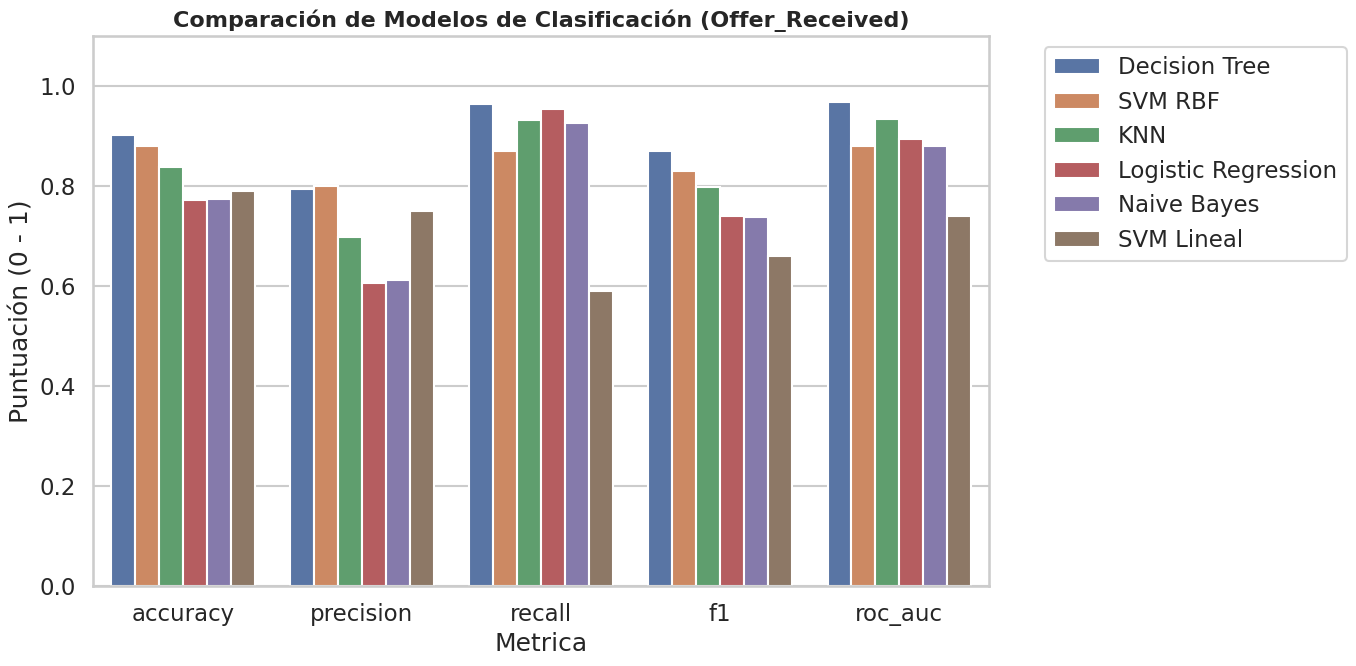

/tmp/ipykernel_186901/4095170831.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regression_df, x="R2_test", y="modelo", palette="viridis")


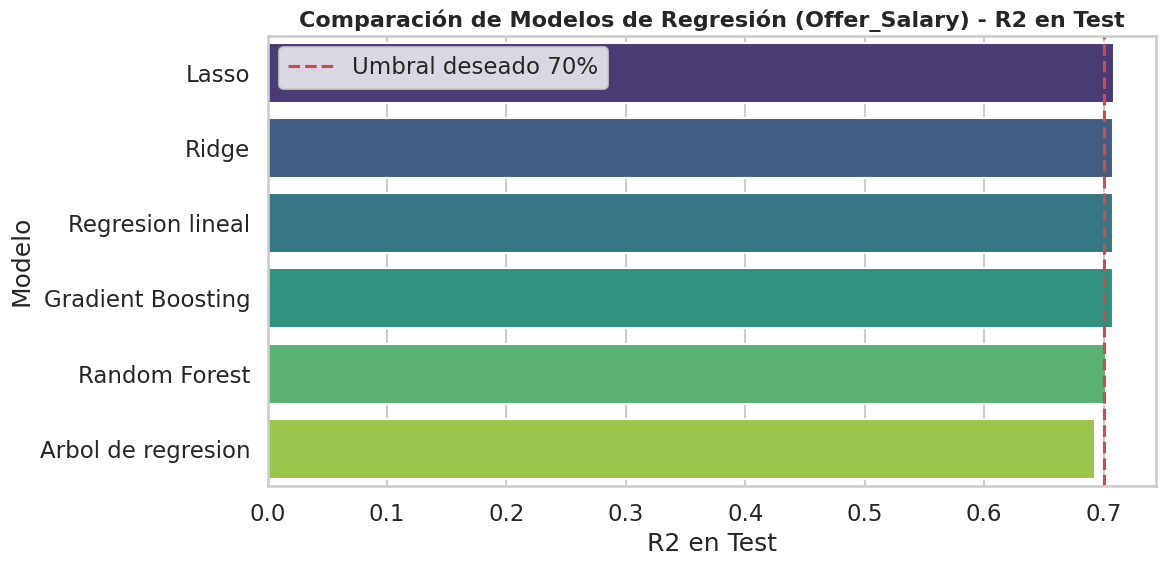

In [26]:
classification_chart = classification_df.melt(
    id_vars=["model"],
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="Metrica",
    value_name="Valor"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=classification_chart, x="Metrica", y="Valor", hue="model")
plt.title("Comparación de Modelos de Clasificación (Offer_Received)", fontsize=16, fontweight="bold")
plt.ylabel("Puntuación (0 - 1)")
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=regression_df, x="R2_test", y="modelo", palette="viridis")
plt.axvline(x=0.70, color="r", linestyle="--", label="Umbral deseado 70%")
plt.title("Comparación de Modelos de Regresión (Offer_Salary) - R2 en Test", fontsize=16, fontweight="bold")
plt.xlabel("R2 en Test")
plt.ylabel("Modelo")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusiones y Decisiones Finales de Negocio

Tras completar los experimentos en las tres áreas de minería de datos (clasificación, regresión y clustering), se han tomado las siguientes decisiones de ingeniería y negocio para el despliegue del proyecto:

### 1. Clasificación (`Offer_Received`)
* **Modelo Seleccionado:** **Decision Tree (Árbol de Decisión)** con umbral de `0.50` (`Accuracy: 90.15%`, `Precision: 79.28%`, `Recall: 96.44%`, `F1: 87.02%`).
* **Justificación Científica:** Supera por un margen significativo a los modelos lineales (Regresión Logística, Naive Bayes) y a KNN. También supera a SVM RBF (F1: 83%). Esto se debe a que las variables predictoras (GPA, pasantías, entrevistas y plataforma de búsqueda) interactúan de manera estrictamente no lineal y jerárquica, características ideales para los árboles de decisión. Adicionalmente, posee una latencia de inferencia de microsegundos, lo que lo hace perfecto para su integración en tiempo real en la API.

### 2. Regresión (`Offer_Salary`)
* **Modelo Seleccionado:** **Lasso** (`R2 Test: 70.85%`, `MAE Test: 6339.79 USD`).
* **Justificación Científica:** La predicción del salario anual ofertado exhibe un comportamiento predominantemente lineal en el espacio de características. Por ello, los modelos lineales regularizados (Lasso y Ridge) superaron a los modelos no lineales más complejos (Random Forest y Gradient Boosting), los cuales tendieron al sobreajuste. **Lasso** (con penalización L1 `alpha=10`) es el ganador por poseer el menor error absoluto medio (MAE) y por su capacidad de simplificar coeficientes no significativos.

### 3. Clustering No Supervisado (Segmentación de Estudiantes)
* **Modelo Seleccionado:** **KMeans ($k=2$)**.
* **Justificación de Negocio:** Aunque el clustering demostró que **la empleabilidad no es un fenómeno divisible en grupos discretos** (por lo que se requirieron modelos supervisados), KMeans identificó dos perfiles de comportamiento de búsqueda de empleo muy consistentes:
  * **Cluster 0 (Usuarios de Handshake):** Estudiantes en universidades pequeñas con búsquedas de empleo muy focalizadas y menor volumen de aplicaciones.
  * **Cluster 1 (Usuarios de LinkedIn/Indeed):** Estudiantes en universidades medianas y grandes que realizan búsquedas masivas, enviando el doble de aplicaciones en promedio.
* **Estrategia de Despliegue:** Exportamos el pipeline de KMeans (`modelo_kmeans_clustering.pkl`) no para predecir el éxito laboral, sino para **enriquecer el perfil de usuario en el frontend**. La plataforma de búsqueda puede clasificar al estudiante en su cluster y mostrarle información estadística contextual (ej. "Los estudiantes de tu perfil suelen aplicar a un promedio de 65 vacantes y prefieren LinkedIn").